### Decision Tree Classifier and Decision Boundary

This notebook demonstrates building a Decision Tree Classifier on the Iris dataset. Steps covered:
1. **Load Data**: Load Iris dataset (using sepal length & width).
2. **Train-Test Split**: Divide data to evaluate model generalization.
3. **Train Model**: Fit a Decision Tree Classifier.
4. **Visualize Tree**: Plot the learned tree rules.
5. **Evaluate**: Calculate training and testing accuracy.
6. **Decision Boundary**: Visualize how the model partitions the feature space.

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score

# 1. Load the Iris dataset
iris = load_iris(as_frame=True)
iris_df = iris.frame

# We use only the first two features (Sepal Length and Sepal Width) for 2D visualization
feature_cols = iris.feature_names[:2]
X = iris_df[feature_cols]
y = iris.target

print("Features taken:", feature_cols)
X.head(3)

Features taken: ['sepal length (cm)', 'sepal width (cm)']


,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2


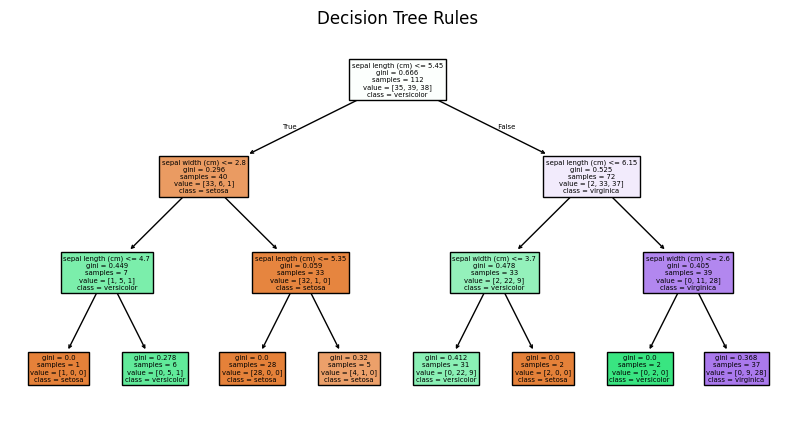

Training Accuracy: 0.82
Testing Accuracy:  0.76


In [ ]:
# 2. Split the data (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

# 3. Train the Decision Tree Classifier
# 'max_depth=3' prevents the tree from becoming arbitrarily deep (reduces overfitting)
dt_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)

# 4. Visualize the trained decision tree rules
plt.figure(figsize=(10, 5))
plot_tree(dt_model, filled=True, feature_names=feature_cols, class_names=list(iris.target_names))
plt.title("Decision Tree Rules")
plt.show()

# 5. Evaluate the model's accuracy
print(f"Training Accuracy: {accuracy_score(y_train, dt_model.predict(X_train)):.2f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, dt_model.predict(X_test)):.2f}")

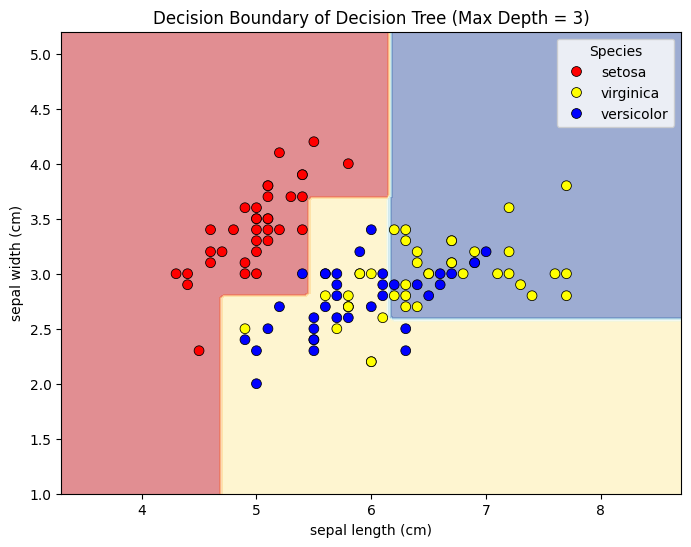

In [22]:
# 6. Visualize the Decision Boundary
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot the decision boundary using the trained model
disp = DecisionBoundaryDisplay.from_estimator(
    dt_model, 
    X_train, 
    response_method="predict",
    cmap=plt.cm.RdYlBu, 
    alpha=0.5,
    ax=ax
)

# Scatter plot of the training data points
sns.scatterplot(x=X_train.iloc[:, 0], y=X_train.iloc[:, 1], hue=iris.target_names[y_train],
                palette=["red", "yellow", "blue"], edgecolor="k", s=50, ax=ax)

plt.title("Decision Boundary of Decision Tree (Max Depth = 3)")
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.legend(title="Species")
plt.show()

### Interpreting the Decision Boundary Plot

- **Rectangular Regions**: Notice that the decision boundaries are all perfectly vertical or horizontal lines. This is a characteristic feature of Decision Trees, as they make splits based on a single feature at a time (e.g., `sepal length <= 5.45`).
- **Colored Areas**: The background colors represent the model's prediction for any given point in that region. If a new flower falls into a specific colored region, it will be classified as the corresponding species.
- **Data Points**: The scatter points represent our actual training data. Points that land in a background color different from their own color indicate misclassifications by the model.
- **Tree Depth**: Because we limited `max_depth=3`, the regions are relatively broad. If the depth were unconstrained, the model might create highly specific, tiny boundaries around individual points to classify everything perfectly, which is a classic sign of **overfitting**.

In [23]:
# 7. Train an Unconstrained Decision Tree Model (No max_depth)
dt_unconstrained = DecisionTreeClassifier(criterion="gini", random_state=42)
dt_unconstrained.fit(X_train, y_train)

print("--- Unconstrained Tree Performance ---")
print(f"Training Accuracy: {accuracy_score(y_train, dt_unconstrained.predict(X_train)):.2f}")
print(f"Testing Accuracy:  {accuracy_score(y_test, dt_unconstrained.predict(X_test)):.2f}")

--- Unconstrained Tree Performance ---
Training Accuracy: 0.96
Testing Accuracy:  0.66


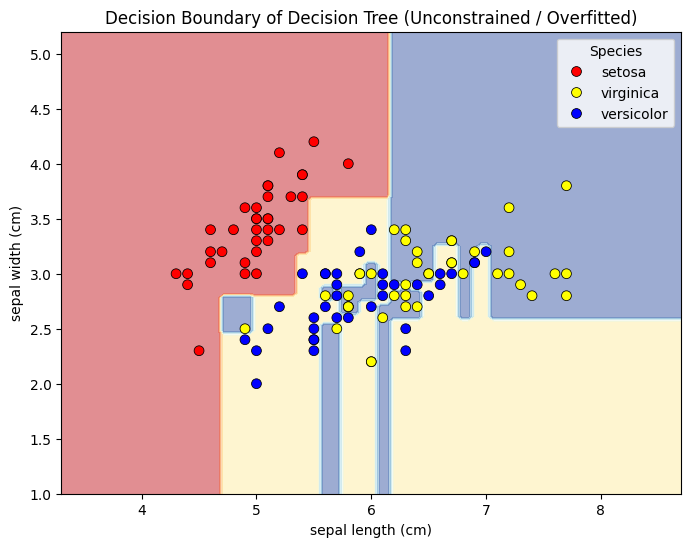

In [24]:
# 8. Visualize the Decision Boundary for the Unconstrained Tree
plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot the decision boundary
disp = DecisionBoundaryDisplay.from_estimator(
    dt_unconstrained, 
    X_train, 
    response_method="predict",
    cmap=plt.cm.RdYlBu, 
    alpha=0.5,
    ax=ax
)

# Scatter plot of the training data points
sns.scatterplot(x=X_train.iloc[:, 0], y=X_train.iloc[:, 1], hue=iris.target_names[y_train],
                palette=["red", "yellow", "blue"], edgecolor="k", s=50, ax=ax)

plt.title("Decision Boundary of Decision Tree (Unconstrained / Overfitted)")
plt.xlabel(feature_cols[0])
plt.ylabel(feature_cols[1])
plt.legend(title="Species")
plt.show()

### Interpreting the Unconstrained Model (`max_depth=None`)

When comparing this boundary to the `max_depth=3` tree, we can observe several key differences:

1. **Highly Complex Boudaries**: Unlike the broad, simple rectangles of the depth-3 tree, the unconstrained tree creates tiny, highly specific boundaries (often just to classify a single stray point correctly).
2. **Training vs. Testing Performance**: 
   - The **Training Accuracy** for the unconstrained model is close to **1.00 (100%)** because the tree kept growing until every training sample was perfectly classified into pure leaf nodes.
   - However, the **Testing Accuracy** often *drops* compared to the `max_depth=3` model.
3. **The Concept of Overfitting**: This proves the model has **overfitted**. It has mapped out random noise and outliers in the training data rather than learning the general underlying pattern of the flower species. As a result, it generalizes poorly to new, unseen data.

> **Key Takeaway**: Controlling the depth of your Decision Tree (or using methods like Random Forests) is essential for building models that perform better on unseen data.